# Building Random Forests from Scratch

**Acknowledgment:** This notebook explores random forests using the Titanic dataset, building on concepts from Jeremy Howard's excellent [fast.ai course](https://course.fast.ai/) and his Kaggle notebook ["How Random Forests Really Work"](https://www.kaggle.com/code/jhoward/how-random-forests-really-work). I've extended the original material with additional feature engineering, alternative impurity measures, and more detailed preprocessing.

## Environment Setup and Data Acquisition

We'll use the classic Titanic dataset, this is a binary classification problem predicting passenger survival based on features like age, sex, and class. It's ideal for understanding how decision trees and random forests extract patterns from real world, messy data.

In [1]:
import numpy as np
import kaggle
from pathlib import Path
np.set_printoptions(linewidth=130)

In [2]:
import zipfile, kaggle

path = Path('titanic')
kaggle.api.competition_download_cli(str(path))
zipfile.ZipFile(f'{path}.zip').extractall(path)

titanic.zip: Skipping, found more recently modified local copy (use --force to force download)


## Loading the Data

The training set includes our target variable `Survived`, while the test set is what we'll predict on for submission.

In [3]:
import pandas as pd

df = pd.read_csv(path/'train.csv')
tst_df = pd.read_csv(path/'test.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Preprocessing Part 1: Handling Missing Values

Real world data is rarely complete. My strategy here is to compute group specific statistics for imputation, using medians stratified by passenger class and sex for Age and Fare. This respects the natural structure in the data better than global imputation.

In [4]:
modes = df.mode().iloc[0]
modes

PassengerId                      1
Survived                       0.0
Pclass                         3.0
Name           Abbing, Mr. Anthony
Sex                           male
Age                           24.0
SibSp                          0.0
Parch                          0.0
Ticket                        1601
Fare                          8.05
Cabin                      B96 B98
Embarked                         S
Name: 0, dtype: object

In [8]:
# Compute statistics from training set
modes = df.mode().iloc[0]
fare_medians = df.groupby('Pclass')['Fare'].median()
age_medians = df.groupby(['Pclass', 'Sex'])['Age'].median()

print(fare_medians)
print()
print(age_medians)

Pclass
1    60.2875
2    14.2500
3     8.0500
Name: Fare, dtype: float64

Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64


## Preprocessing Part 2: Feature Engineering

The `proc_data` function handles several enhancements:

- **CabinKnown**: Binary flag for whether cabin info exists (proxy for passenger status)
- **Title**: Extracted from names (Mr., Mrs., etc.), encodes social information
- **FamilySize** and **IsAlone**: Capture travel group dynamics
- **LogFare**: Log-transform to handle the skewed fare distribution
- **Stratified imputation**: Age and Fare filled using class/sex-specific medians

In [11]:
def proc_data(df):
    # Create new features
    df['CabinKnown'] = df['Cabin'].notna().astype(int)
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    
    # Fill missing values with stratified statistics
    df['Fare'] = df['Fare'].fillna(df['Pclass'].map(fare_medians))
    df['Age'] = df['Age'].fillna(df.apply(
        lambda row: age_medians[row['Pclass'], row['Sex']] if pd.isna(row['Age']) else row['Age'], axis=1))
    df.fillna(modes, inplace=True)
    
    # Log transform for skewed fare
    df['LogFare'] = np.log1p(df['Fare'])
    
    # Convert to categorical
    for col in ['Sex', 'Embarked', 'Title', 'Pclass', 'IsAlone']:
        df[col] = pd.Categorical(df[col])

proc_data(df)
proc_data(tst_df)

In [12]:
cats = ['Sex', 'Embarked', 'Title', 'Pclass', 'IsAlone']
conts = ['Age', 'SibSp', 'Parch', 'LogFare', 'FamilySize', 'CabinKnown']
dep = 'Survived'

print(df[cats + conts + [dep]].head())

      Sex Embarked Title Pclass IsAlone   Age  SibSp  Parch   LogFare  \
0    male        S    Mr      3       0  22.0      1      0  2.110213   
1  female        C   Mrs      1       0  38.0      1      0  4.280593   
2  female        S  Miss      3       1  26.0      0      0  2.188856   
3  female        S   Mrs      1       0  35.0      1      0  3.990834   
4    male        S    Mr      3       1  35.0      0      0  2.202765   

   FamilySize  CabinKnown  Survived  
0           2           1         0  
1           2           1         1  
2           1           1         1  
3           2           1         1  
4           1           1         0  


## Exploratory Data Analysis

Before modeling, let's visualize some key relationships. The famous "women and children first" policy should be visible in the data.

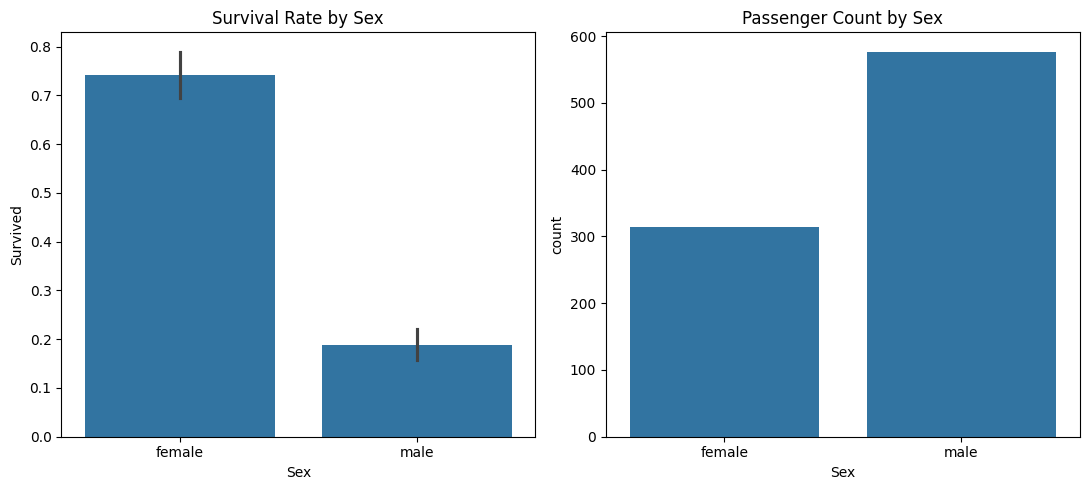

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(11, 5))
sns.barplot(data=df, y=dep, x="Sex", ax=axs[0]).set(title="Survival Rate by Sex")
sns.countplot(data=df, x="Sex", ax=axs[1]).set(title="Passenger Count by Sex")
plt.tight_layout()
plt.show()

## Preparing for Modeling

Split into train/validation sets and convert categoricals to numeric codes for the tree algorithms.

In [14]:
from numpy import random
from sklearn.model_selection import train_test_split

random.seed(42)
trn_df, val_df = train_test_split(df, test_size=0.2)
trn_df[cats] = trn_df[cats].apply(lambda x: x.cat.codes)
val_df[cats] = val_df[cats].apply(lambda x: x.cat.codes)

trn_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,CabinKnown,Title,FamilySize,IsAlone,LogFare
331,332,0,0,"Partner, Mr. Austen",1,45.5,0,0,113043,28.5000,C124,2,1,12,1,1,3.384390
733,734,0,1,"Berriman, Mr. William John",1,23.0,0,0,28425,13.0000,B96 B98,2,1,12,1,1,2.639057
382,383,0,2,"Tikkanen, Mr. Juho",1,32.0,0,0,STON/O 2. 3101293,7.9250,B96 B98,2,1,12,1,1,2.188856
704,705,0,2,"Hansen, Mr. Henrik Juul",1,26.0,1,0,350025,7.8542,B96 B98,2,1,12,2,0,2.180892
813,814,0,2,"Andersson, Miss. Ebba Iris Alfrida",0,6.0,4,2,347082,31.2750,B96 B98,2,1,9,7,0,3.474293


In [15]:
def extract_features_target(dataframe, feature_cols, target_col):
    """Separate features (X) from target (y) for modeling."""
    X = dataframe[feature_cols].copy()
    y = dataframe[target_col] if target_col in dataframe else None
    return X, y

trn_xs, trn_y = extract_features_target(trn_df, cats + conts, dep)
val_xs, val_y = extract_features_target(val_df, cats + conts, dep)

## Baseline: The "OneR" Model (OneR[ule] model)

Before building complex models, establish a baseline. Given the EDA, predicting survival based solely on sex (females survive) is a reasonable starting point.

In [16]:
preds = val_xs.Sex == 0  # 0 = female after cat.codes

In [17]:
from sklearn.metrics import mean_absolute_error
print(f"Baseline MAE (sex-only rule): {mean_absolute_error(val_y, preds):.4f}")

Baseline MAE (sex-only rule): 0.2179


## More EDA: Fare Distribution

Let's examine how LogFare relates to survival, lets do then a continuous variable analysis.

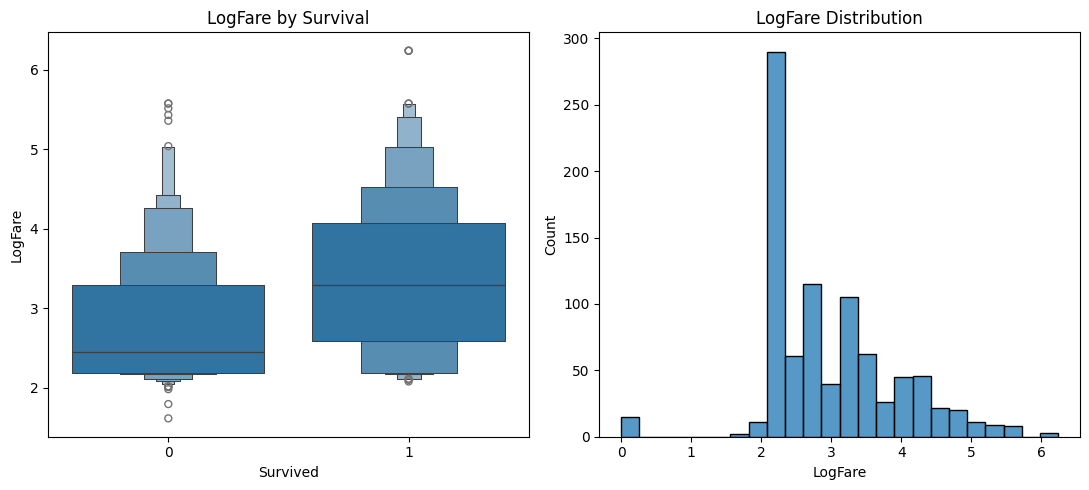

In [18]:
df_fare = trn_df[trn_df.LogFare > 0]
fig, axs = plt.subplots(1, 2, figsize=(11, 5))
sns.boxenplot(data=df_fare, x=dep, y="LogFare", ax=axs[0])
axs[0].set_title("LogFare by Survival")
sns.histplot(data=df, x="LogFare", ax=axs[1])
axs[1].set_title("LogFare Distribution")
plt.tight_layout()
plt.show()

## Understanding Decision Tree Splits: Gini Impurity

Decision trees work by recursively partitioning data to maximize class separation. **Gini impurity** measures how "mixed" a node's labels are:

$$\text{Gini}(S) = 1 - \sum_{i} p_i^2$$

For binary classification: $\text{Gini} = 1 - p^2 - (1-p)^2 = 2p(1-p)$

- **Gini = 0**: Pure node (all same class)
- **Gini = 0.5**: Maximum impurity (50-50 split)

P is the probability of a sample belonging to a class, its the frequency of the positive class in a binary settings. 

In [19]:
def compute_gini(labels):
    """
    Calculate Gini impurity for a set of binary labels.
    
    Gini = 1 - sum(p_i^2) = 2*p*(1-p) for binary case
    """
    if len(labels) == 0:
        return 0
    p = labels.mean()
    return 2 * p * (1 - p)

In [20]:
print(f"Initial Gini (before any split): {compute_gini(trn_df[dep]):.4f}")

Initial Gini (before any split): 0.4694


## Information Gain: Evaluating Split Quality

A good split reduces impurity. **Information gain** measures this reduction:

$$\text{Gain} = \text{Gini}_{\text{parent}} - \frac{n_{\text{left}}}{n}\text{Gini}_{\text{left}} - \frac{n_{\text{right}}}{n}\text{Gini}_{\text{right}}$$

Since lower impurity is better, we want the weighted average of the children’s impurities ($\frac{n_{\text{left}}}{n}\text{Gini}_{\text{left}} + \frac{n_{\text{right}}}{n}\text{Gini}_{\text{right}}$) to be as small as possible (0), making the gain as large as possible, ideally it would be equal to the parent Gini. 

In [22]:
def compute_split_gain(df, condition, target='Survived'):
    """
    Calculate information gain from splitting df by condition.
    
    Returns: gain = parent_impurity - weighted_child_impurity
    """
    parent_gini = compute_gini(df[target])
    
    left_mask = condition
    left_df = df[left_mask]
    right_df = df[~left_mask]
    
    n_total = len(df)
    n_left = len(left_df)
    n_right = len(right_df)
    
    if n_left == 0 or n_right == 0:
        return 0
    
    weighted_child_gini = (
        (n_left / n_total) * compute_gini(left_df[target]) +
        (n_right / n_total) * compute_gini(right_df[target])
    )
    
    return parent_gini - weighted_child_gini

In [23]:
# Test some splits
print(f"Gain from Sex == male: {compute_split_gain(df, df.Sex == 'male'):.4f}")
print(f"Gain from LogFare < 2.7: {compute_split_gain(df, df.LogFare < 2.7):.4f}")

Gain from Sex == male: 0.1396
Gain from LogFare < 2.7: 0.0320


In [24]:
# Interactive exploration
conds = ['<', '=']

def interactive_score(feature, split, cnd):
    if cnd == '<':
        return compute_split_gain(trn_df, trn_df[feature] > split)
    else:
        return compute_split_gain(trn_df, trn_df[feature] == split)

from ipywidgets import interact
interact(feature=conts+cats, split=15.5, cnd=conds)(interactive_score);

interactive(children=(Dropdown(description='feature', options=('Age', 'SibSp', 'Parch', 'LogFare', 'FamilySize…

## Finding Optimal Split Points

For each feature, we search over possible thresholds to find the split maximizing information gain.

In [25]:
nm = "Age"
col = trn_df[nm]
unique_vals = col.dropna().unique()
unique_vals.sort()
print(f"Unique {nm} values: {len(unique_vals)}")

Unique Age values: 84


In [26]:
def find_best_threshold(df, feature_name, target='Survived'):
    """
    Find the threshold that maximizes information gain for a feature.
    
    Returns: (best_threshold, best_gain)
    """
    col = df[feature_name]
    unique_vals = col.dropna().unique()
    
    gains = []
    valid_thresholds = []
    
    for thresh in unique_vals:
        if np.isnan(thresh):
            continue
        gain = compute_split_gain(df, df[feature_name] <= thresh, target)
        gains.append(gain)
        valid_thresholds.append(thresh)
    
    if not gains:
        return None, 0
    
    gains = np.array(gains)
    best_idx = gains.argmax()
    return valid_thresholds[best_idx], gains[best_idx]

find_best_threshold(df, "Age")

(np.float64(6.0), np.float64(0.011283125505412883))

In [27]:
# Find best split for each feature
cols = cats + conts
feature_splits = {col: find_best_threshold(trn_df, col) for col in cols}

print("Best splits by feature (threshold, gain):")
for feat, (thresh, gain) in sorted(feature_splits.items(), key=lambda x: -x[1][1]):
    print(f"  {feat:12s}: {thresh:8.2f}  gain={gain:.4f}" if isinstance(thresh, float) else f"  {feat:12s}: {thresh}  gain={gain:.4f}")

Best splits by feature (threshold, gain):
  Sex         : 0  gain=0.1378
  Title       : 12  gain=0.0584
  Pclass      : 1  gain=0.0463
  LogFare     :     2.44  gain=0.0386
  IsAlone     : 0  gain=0.0153
  FamilySize  : 1  gain=0.0153
  Embarked    : 0  gain=0.0120
  Age         :     5.00  gain=0.0116
  Parch       : 0  gain=0.0092
  SibSp       : 3  gain=0.0059
  CabinKnown  : 1  gain=0.0000


## Gini Alternative, Classical entropy (information theory)

Instead of Gini, you can measure how “mixed” a node is using **entropy**, aka cross-entropy:

$$H(S) = -\sum_{i} p_i \log_2(p_i)$$

For **binary** classification:

$$H(p) = -p\log_2 p - (1-p)\log_2(1-p)$$

- **Entropy = 0** when the node is pure (\(p=0\) or \(p=1\))
- **Entropy is maximum at \(p=0.5\)** (most uncertainty)

## Information gain (with entropy)

A split is good if it reduces entropy. **Information gain** is:

$$IG = H(\text{parent}) - \frac{n_L}{n}H(\text{left}) - \frac{n_R}{n}H(\text{right})$$

So maximizing \(IG\) is equivalent to minimizing the **weighted child entropy**:

$$\frac{n_L}{n}H(\text{left}) + \frac{n_R}{n}H(\text{right})$$


In [28]:
def compute_entropy(labels):
    """
    Calculate entropy (binary entropy) for a set of labels.
    
    H = -p*log(p) - (1-p)*log(1-p)
    """
    if len(labels) == 0:
        return 0
    p = labels.mean()
    if p == 0 or p == 1:
        return 0  # Pure node has zero entropy
    return -p * np.log(p) - (1 - p) * np.log(1 - p)

In [29]:
def compute_split_gain_ce(df, condition, target='Survived'):
    """
    Calculate information gain using entropy instead of Gini.
    """
    parent_ce = compute_entropy(df[target])
    
    left_df = df[condition]
    right_df = df[~condition]
    
    n_total = len(df)
    n_left = len(left_df)
    n_right = len(right_df)
    
    if n_left == 0 or n_right == 0:
        return 0
    
    weighted_child_ce = (
        (n_left / n_total) * compute_entropy(left_df[target]) +
        (n_right / n_total) * compute_entropy(right_df[target])
    )
    
    return parent_ce - weighted_child_ce

In [30]:
def find_best_threshold_ce(df, feature_name, target='Survived'):
    """Find best threshold using entropy."""
    col = df[feature_name]
    unique_vals = col.dropna().unique()
    
    gains = []
    valid_thresholds = []
    
    for thresh in unique_vals:
        if np.isnan(thresh):
            continue
        gain = compute_split_gain_ce(df, df[feature_name] <= thresh, target)
        gains.append(gain)
        valid_thresholds.append(thresh)
    
    if not gains:
        return None, 0
    
    gains = np.array(gains)
    best_idx = gains.argmax()
    return valid_thresholds[best_idx], gains[best_idx]

# Compare Gini vs Entropy
print("Entropy best splits:")
for col in cols:
    thresh, gain = find_best_threshold_ce(trn_df, col)
    print(f"  {col}: {thresh}, gain={gain:.4f}")

Entropy best splits:
  Sex: 0, gain=0.1493
  Embarked: 0, gain=0.0124
  Title: 12, gain=0.0614
  Pclass: 1, gain=0.0498
  IsAlone: 0, gain=0.0162
  Age: 5.0, gain=0.0119
  SibSp: 4, gain=0.0080
  Parch: 0, gain=0.0096
  LogFare: 2.4390808375825834, gain=0.0431
  FamilySize: 1, gain=0.0162
  CabinKnown: 1, gain=0.0000


## Subgroup Analysis: Beyond the First Split

Since Sex dominates, let's see what features matter *within* each sex group, this mimics how a decision tree continues splitting.

In [31]:
cols_no_sex = [c for c in cols if c != 'Sex']
is_male = trn_df.Sex == 1
males, females = trn_df[is_male], trn_df[~is_male]

In [32]:
print("Best splits for MALES:")
for col in cols_no_sex:
    thresh, gain = find_best_threshold(males, col)
    print(f"  {col}: {thresh}, gain={gain:.4f}")

Best splits for MALES:
  Embarked: 0, gain=0.0049
  Title: 8, gain=0.0215
  Pclass: 0, gain=0.0124
  IsAlone: 0, gain=0.0043
  Age: 6.0, gain=0.0243
  SibSp: 0, gain=0.0025
  Parch: 0, gain=0.0047
  LogFare: 3.305053521109253, gain=0.0124
  FamilySize: 1, gain=0.0043
  CabinKnown: 1, gain=0.0000


In [33]:
print("Best splits for FEMALES:")
for col in cols_no_sex:
    thresh, gain = find_best_threshold(females, col)
    print(f"  {col}: {thresh}, gain={gain:.4f}")

Best splits for FEMALES:
  Embarked: 0, gain=0.0115
  Title: 9, gain=0.0141
  Pclass: 1, gain=0.1122
  IsAlone: 0, gain=0.0030
  Age: 21.5, gain=0.0223
  SibSp: 2, gain=0.0301
  Parch: 3, gain=0.0227
  LogFare: 3.8691155044168695, gain=0.0279
  FamilySize: 4, gain=0.0570
  CabinKnown: 1, gain=0.0000


## Building Decision Trees with Scikit-Learn

Now let's use sklearn's implementation and visualize the resulting trees.

In [34]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz

# Small tree for visualization
small_tree = DecisionTreeClassifier(max_leaf_nodes=4, random_state=42)
small_tree.fit(trn_xs, trn_y);

In [35]:
import graphviz
import re

def visualize_tree(tree_model, feature_names, size=10, ratio=0.6, precision=2, **kwargs):
    """
    Create a graphviz visualization of a decision tree.
    """
    dot_data = export_graphviz(
        tree_model, 
        out_file=None, 
        feature_names=feature_names, 
        filled=True, 
        rounded=True,
        special_characters=True, 
        rotate=False, 
        precision=precision, 
        **kwargs
    )
    # Adjust graph size
    dot_data = re.sub('Tree {', f'Tree {{ size={size}; ratio={ratio}', dot_data)
    return graphviz.Source(dot_data)

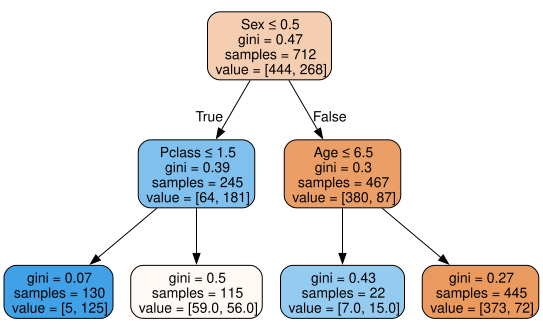

In [36]:
visualize_tree(small_tree, trn_xs.columns, size=10)

In [37]:
print(f"Small tree MAE: {mean_absolute_error(val_y, small_tree.predict(val_xs)):.4f}")

Small tree MAE: 0.2346


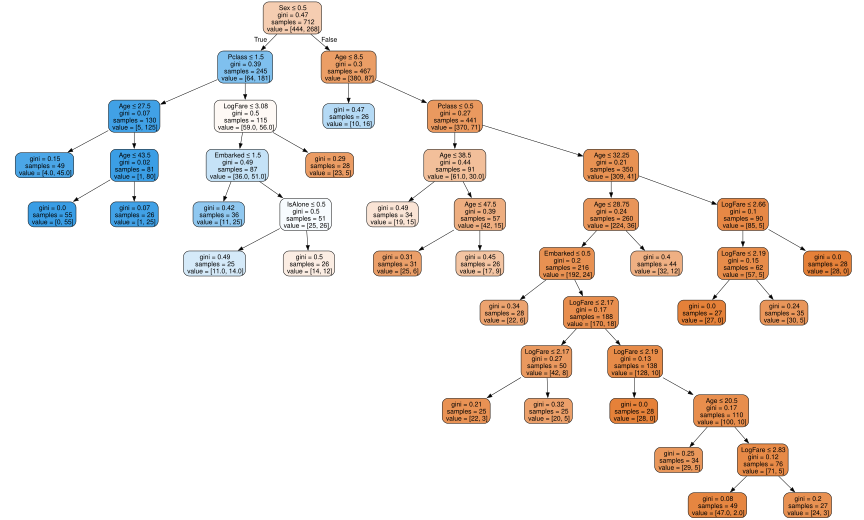

In [38]:
# Larger tree with regularization
reg_tree = DecisionTreeClassifier(min_samples_leaf=25, random_state=42)
reg_tree.fit(trn_xs, trn_y)
visualize_tree(reg_tree, trn_xs.columns, size=12)

In [39]:
print(f"Regularized tree MAE: {mean_absolute_error(val_y, reg_tree.predict(val_xs)):.4f}")

Regularized tree MAE: 0.2067


## Preparing Test Submission

In [40]:
tst_df[cats] = tst_df[cats].apply(lambda x: x.cat.codes)
tst_xs, _ = extract_features_target(tst_df, cats + conts, dep)

def save_submission(predictions, suffix):
    tst_df['Survived'] = predictions
    submission = tst_df[['PassengerId', 'Survived']]
    submission.to_csv(f'sub-{suffix}.csv', index=False)
    print(f"Saved sub-{suffix}.csv")

save_submission(reg_tree.predict(tst_xs), 'tree')

Saved sub-tree.csv


## Building a Random Forest from Scratch

A **random forest** is an ensemble of decision trees where:
1. Each tree is trained on a random subset of the data (bagging)
2. Predictions are averaged across all trees

This reduces variance compared to a single tree. The key insight: **uncorrelated errors cancel out** when averaged, while the true signal reinforces.

In [41]:
def train_bagged_tree(X, y, sample_fraction=0.80):
    """
    Train a single decision tree on a random subset of the data.
    
    This is the core building block of a random forest.
    """
    n_samples = len(y)
    sample_indices = random.choice(n_samples, int(n_samples * sample_fraction), replace=False)
    
    tree = DecisionTreeClassifier(min_samples_leaf=10, random_state=None)
    tree.fit(X.iloc[sample_indices], y.iloc[sample_indices])
    return tree

In [42]:
# Build ensemble of 25 trees
n_trees = 25
forest = [train_bagged_tree(trn_xs, trn_y) for _ in range(n_trees)]
print(f"Built forest with {len(forest)} trees")

Built forest with 25 trees


In [43]:
# Ensemble prediction: average all trees
tree_predictions = np.array([tree.predict(val_xs) for tree in forest])
ensemble_pred = tree_predictions.mean(axis=0)

print(f"Manual Random Forest MAE: {mean_absolute_error(val_y, ensemble_pred):.4f}")

Manual Random Forest MAE: 0.2051


## Using Scikit-Learn's RandomForestClassifier

The sklearn implementation adds one more trick: **random feature subsets** at each split, further decorrelating the trees.

In [44]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=25, min_samples_leaf=5, random_state=42)
rf.fit(trn_xs, trn_y)

print(f"Sklearn Random Forest MAE: {mean_absolute_error(val_y, rf.predict(val_xs)):.4f}")

Sklearn Random Forest MAE: 0.1788


In [45]:
save_submission(rf.predict(tst_xs), 'rf')

Saved sub-rf.csv


## Feature Importance Analysis

Random forests provide built-in feature importance based on how much each feature contributes to reducing impurity across all trees.

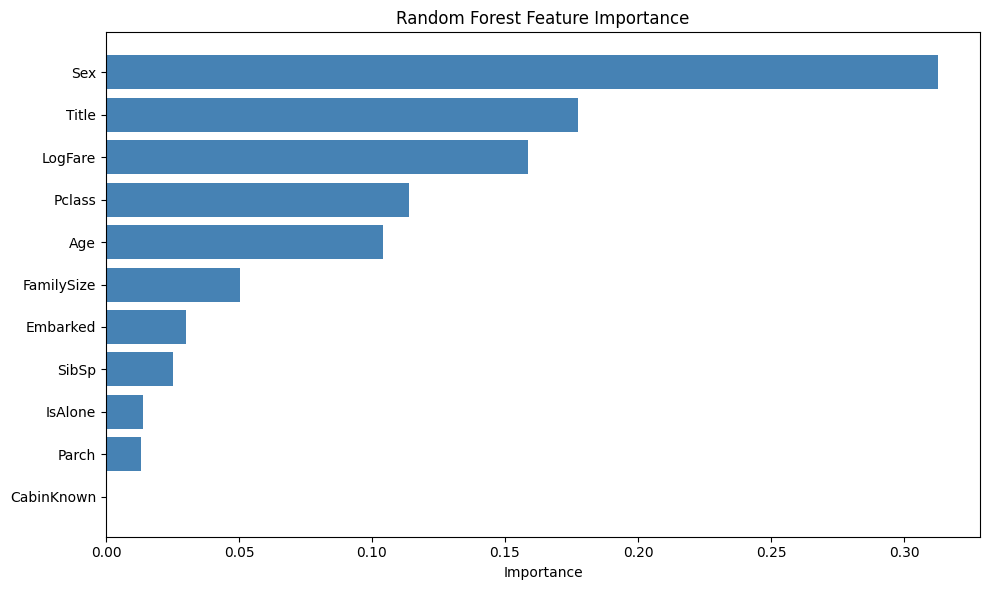

In [46]:
importance_df = pd.DataFrame({
    'feature': trn_xs.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

## Summary

In this notebook we:

1. **Preprocessed** the Titanic data with enhanced feature engineering (Title, FamilySize, etc.)
2. **Explored** impurity measures: Gini impurity and cross-entropy
3. **Implemented** information gain calculation from scratch
4. **Built** decision trees with sklearn and visualized them
5. **Constructed** a random forest manually to understand bagging
6. **Compared** our manual forest to sklearn's optimized implementation
7. **Analyzed** feature importance to understand what drives predictions

Key insight: Sex remains the dominant predictor ("women and children first"), but combining multiple features through tree ensembles can capture more nuanced patterns.